In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist
import os

In [3]:
data_path = "../Dataset/Scott_2001/monkey_data.csv"
# filename = "experiment_data.csv"
# filepath = os.path.join("..", filename)
monkey_df = pd.read_csv(data_path)
monkey_df

,Subject_Id,Session_No,Trial_No,Time,HandPos,TargetPos
0,Scott_2001_e1,1,1,[0.006;0.016;0.026;0.036;0.046;0.056;0.066;0.0...,[-13.166 280.695;-13.3428 280.618;-13.5578 280...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...
1,Scott_2001_e1,1,2,[0.052;0.062;0.072;0.082;0.092;0.102;0.112;0.1...,[-18.7382 283.289;-19.4048 282.418;-19.9414 28...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...
2,Scott_2001_e1,1,3,[1.064;1.074;1.084;1.094;1.104;1.114;1.124;1.1...,[-20.5466 283.837;-20.168 283.326;-19.64 282.8...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...
3,Scott_2001_e1,1,4,[0.352;0.362;0.372;0.382;0.392;0.402;0.412;0.4...,[-14.548 281.899;-14.9 281.372;-15.251 280.844...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...
4,Scott_2001_e1,1,5,[0.046;0.056;0.066;0.076;0.086;0.096;0.106;0.1...,[-20.558 279.653;-20.508 279.572;-20.293 279.5...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...
...,...,...,...,...,...,...
23634,Scott_2001_e5,88,16,[0.681;0.691;0.701;0.711;0.721;0.731;0.741;0.7...,[-5.489 295.829;-5.39344 295.876;-5.1416 295.8...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...
23635,Scott_2001_e5,88,17,[0.47;0.48;0.49;0.5;0.51;0.52;0.53;0.54;0.55;0...,[-0.2296 289.508;-0.537 289.575;-0.81 289.659;...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...
23636,Scott_2001_e5,88,18,[0.3;0.31;0.32;0.33;0.34;0.35;0.36;0.37;0.38;0...,[-6.225 295.896;-6.225 295.896;-6.0372 295.957...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...
23637,Scott_2001_e5,88,19,[0.16;0.17;0.18;0.19;0.2;0.21;0.22;0.23;0.24;0...,[-9.774 288.568;-9.774 288.568;-9.774 288.568;...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...


In [4]:
def matlab_time_to_array(matlab_str):
    # Remove brackets
    matlab_str = matlab_str.strip('[]')
    # Split by semicolons
    values = matlab_str.split(';')
    # Convert to float and create numpy array
    return np.array([float(val) for val in values])

# Apply the conversion function to the 'Time' column
monkey_df['time_diff_ms'] = monkey_df['Time'].apply(matlab_time_to_array)
monkey_df["time_diff_ms"]

0        [0.006, 0.016, 0.026, 0.036, 0.046, 0.056, 0.0...
1        [0.052, 0.062, 0.072, 0.082, 0.092, 0.102, 0.1...
2        [1.064, 1.074, 1.084, 1.094, 1.104, 1.114, 1.1...
3        [0.352, 0.362, 0.372, 0.382, 0.392, 0.402, 0.4...
4        [0.046, 0.056, 0.066, 0.076, 0.086, 0.096, 0.1...
                               ...                        
23634    [0.681, 0.691, 0.701, 0.711, 0.721, 0.731, 0.7...
23635    [0.47, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54...
23636    [0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37...
23637    [0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23...
23638    [0.005, 0.015, 0.025, 0.035, 0.045, 0.055, 0.0...
Name: time_diff_ms, Length: 23639, dtype: object

In [5]:
def handpos_to_path(handpos_str):
    # Remove brackets
    handpos_str = handpos_str.strip('[]')
    # Split by semicolons to get each point
    point_strings = handpos_str.split(';')
    
    # Create list of (x,y) tuples
    path = []
    for point_str in point_strings:
        # Split by space to get x and y values
        coords = point_str.strip().split()
        if len(coords) >= 2:  # Ensure we have at least x and y values
            x = float(coords[0])
            y = float(coords[1])
            path.append((x, y))
    
    return path

# Apply the conversion function to the HandPos column
monkey_df['path'] = monkey_df['HandPos'].apply(handpos_to_path)
monkey_df["path"]

0        [(-13.166, 280.695), (-13.3428, 280.618), (-13...
1        [(-18.7382, 283.289), (-19.4048, 282.418), (-1...
2        [(-20.5466, 283.837), (-20.168, 283.326), (-19...
3        [(-14.548, 281.899), (-14.9, 281.372), (-15.25...
4        [(-20.558, 279.653), (-20.508, 279.572), (-20....
                               ...                        
23634    [(-5.489, 295.829), (-5.39344, 295.876), (-5.1...
23635    [(-0.2296, 289.508), (-0.537, 289.575), (-0.81...
23636    [(-6.225, 295.896), (-6.225, 295.896), (-6.037...
23637    [(-9.774, 288.568), (-9.774, 288.568), (-9.774...
23638    [(-10.01, 290.327), (-10.01, 290.327), (-10.01...
Name: path, Length: 23639, dtype: object

In [6]:
monkey_df['TargetPos']

0        [23 320;23 320;23 320;23 320;23 320;23 320;23 ...
1        [23 320;23 320;23 320;23 320;23 320;23 320;23 ...
2        [23 320;23 320;23 320;23 320;23 320;23 320;23 ...
3        [23 320;23 320;23 320;23 320;23 320;23 320;23 ...
4        [23 320;23 320;23 320;23 320;23 320;23 320;23 ...
                               ...                        
23634    [-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...
23635    [-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...
23636    [-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...
23637    [-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...
23638    [-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...
Name: TargetPos, Length: 23639, dtype: object

In [7]:
import re
def extract_single_target(target_pos_str):
    # Extract the first position only since all are the same in each row
    match = re.search(r'\[([-\d.]+)\s+([-\d.]+)', target_pos_str)
    if match:
        x = float(match.group(1))
        y = float(match.group(2))
        return (x, y)
    return None  # Return None if no match found

# Apply the function to the TargetPos column
monkey_df['target_poisiton'] = monkey_df['TargetPos'].apply(extract_single_target)
monkey_df["target_poisiton"]

0        (23.0, 320.0)
1        (23.0, 320.0)
2        (23.0, 320.0)
3        (23.0, 320.0)
4        (23.0, 320.0)
             ...      
23634    (-7.0, 229.0)
23635    (-7.0, 229.0)
23636    (-7.0, 229.0)
23637    (-7.0, 229.0)
23638    (-7.0, 229.0)
Name: target_poisiton, Length: 23639, dtype: object

In [8]:
monkey_df.columns

Index(['Subject_Id', 'Session_No', 'Trial_No', 'Time', 'HandPos', 'TargetPos',
       'time_diff_ms', 'path', 'target_poisiton'],
      dtype='object')

### Trajectroy processing and normalization

In [9]:
def normalize_trajectory_3d(trajectory, time_sequence, target_position=np.array([1.0, 0.0])):
    """
    Normalize trajectory spatially to start at (0,0) and end at (1,0) while preserving original time.
    
    Args:
        trajectory: numpy array of shape (num_points, 2) containing x,y coordinates
        time_sequence: numpy array of timestamps in milliseconds for each point
        target_position: desired end position for all trajectories (default: [1,0])
    
    Returns:
        Normalized 3D trajectory (x, y, time_in_seconds)
    """
    # Convert time from milliseconds to seconds
    time_sequence_seconds = time_sequence
    
    # Spatial normalization - center to (0,0)
    start_pos = trajectory[0]
    centered = trajectory - start_pos
    
    # Get current target position after centering
    current_target = centered[-1]
    
    # Calculate rotation angle to align with desired target
    current_angle = np.arctan2(current_target[1], current_target[0])
    desired_angle = np.arctan2(target_position[1], target_position[0])
    rotation_angle = desired_angle - current_angle
    
    # Create rotation matrix
    cos_theta = np.cos(rotation_angle)
    sin_theta = np.sin(rotation_angle)
    rotation_matrix = np.array([[cos_theta, -sin_theta],
                               [sin_theta, cos_theta]])
    
    # Rotate trajectory
    rotated = np.dot(centered, rotation_matrix.T)
    
    # Scale to match target length
    current_length = np.linalg.norm(rotated[-1])
    target_length = np.linalg.norm(target_position)
    scale_factor = target_length / current_length if current_length > 0 else 1
    
    normalized_spatial = rotated * scale_factor
    
    # Create 3D trajectory with time in seconds
    trajectory_3d = np.column_stack((normalized_spatial, time_sequence_seconds))
    
    return trajectory_3d

def normalize_trajectory_sequence_3d(path, time_diff_ms, target_position=np.array([1.0, 0.0]), target_length=512):
    """
    Normalize a trajectory into 3D (x, y, time_in_seconds).
    
    Args:
        path: trajectory coordinates as list of tuples or numpy array
        time_diff_ms: time differences in milliseconds as list or numpy array
        target_position: desired end position (default: [1,0])
        target_length: desired number of points after resampling (default: 512)
    
    Returns:
        Normalized 3D trajectory with time in seconds
    """
    # Convert input trajectory to numpy array if it's not already
    if isinstance(path, list):
        trajectory = np.array(path)
    else:
        trajectory = path
    
    # Convert time sequence to numpy array if it's not already
    if isinstance(time_diff_ms, list):
        time_sequence = np.array(time_diff_ms)
    else:
        time_sequence = time_diff_ms
    
    norm_traj_3d = np.array([])
    
    if isinstance(trajectory, np.ndarray) and len(trajectory) > 1 and not np.all(trajectory == trajectory[0]):
        # Normalize to 3D with time in seconds
        norm_traj_3d = normalize_trajectory_3d(trajectory, time_sequence, target_position)
        
        # Optional resampling (only for spatial coordinates)
        if target_length is not None and target_length > 2:
            t = np.linspace(0, 1, target_length)
            t_original = np.linspace(0, 1, len(norm_traj_3d))
            
            # Resample spatial coordinates
            resampled_spatial = np.vstack([
                np.interp(t, t_original, norm_traj_3d[:, 0]),
                np.interp(t, t_original, norm_traj_3d[:, 1])
            ]).T
            
            # Resample time to maintain correspondence
            resampled_time = np.interp(t, t_original, norm_traj_3d[:, 2])
            
            norm_traj_3d = np.column_stack((resampled_spatial, resampled_time))
    
    return norm_traj_3d

# Usage with dataframe
def apply_normalization(row):
    # Extract target position from row
    target_pos = row['target_poisiton']
    
    # Create numpy array from path data
    path_array = np.array(row['path'])
    
    # Create numpy array from time data
    time_array = np.array(row['time_diff_ms'])
    
    # Normalize trajectory
    return normalize_trajectory_sequence_3d(path_array, time_array, 
                                           target_position=np.array([1.0, 0.0]),
                                           target_length=512)

In [10]:
monkey_df['normalized_trajectory'] = monkey_df.apply(apply_normalization, axis=1)

In [11]:
monkey_df['normalized_trajectory']

0        [[0.0, 0.0, 0.006], [-0.002538152495614146, 0....
1        [[0.0, 0.0, 0.052], [-0.01694837242217094, -0....
2        [[0.0, 0.0, 1.064], [-0.0008987030711237224, -...
3        [[0.0, 0.0, 0.352], [-0.008492726663542127, -0...
4        [[0.0, 0.0, 0.046], [-0.00039278571450335084, ...
                               ...                        
23634    [[0.0, 0.0, 0.681], [-0.0005254252526689135, 0...
23635    [[0.0, 0.0, 0.47], [-0.0004468164968909544, -0...
23636    [[0.0, 0.0, 0.3], [0.0, 0.0, 0.308982387475538...
23637    [[0.0, 0.0, 0.16], [0.0, 0.0, 0.16720156555772...
23638    [[0.0, 0.0, 0.005], [0.0, 0.0, 0.0133170254403...
Name: normalized_trajectory, Length: 23639, dtype: object

Combined figure saved to: ./plots/monkey/trajectories_combined_Scott_2001_e2_session_2.png
Original trajectories saved to: ./plots/monkey/trajectories_original_Scott_2001_e2_session_2.png
Normalized trajectories saved to: ./plots/monkey/trajectories_normalized_Scott_2001_e2_session_2.png


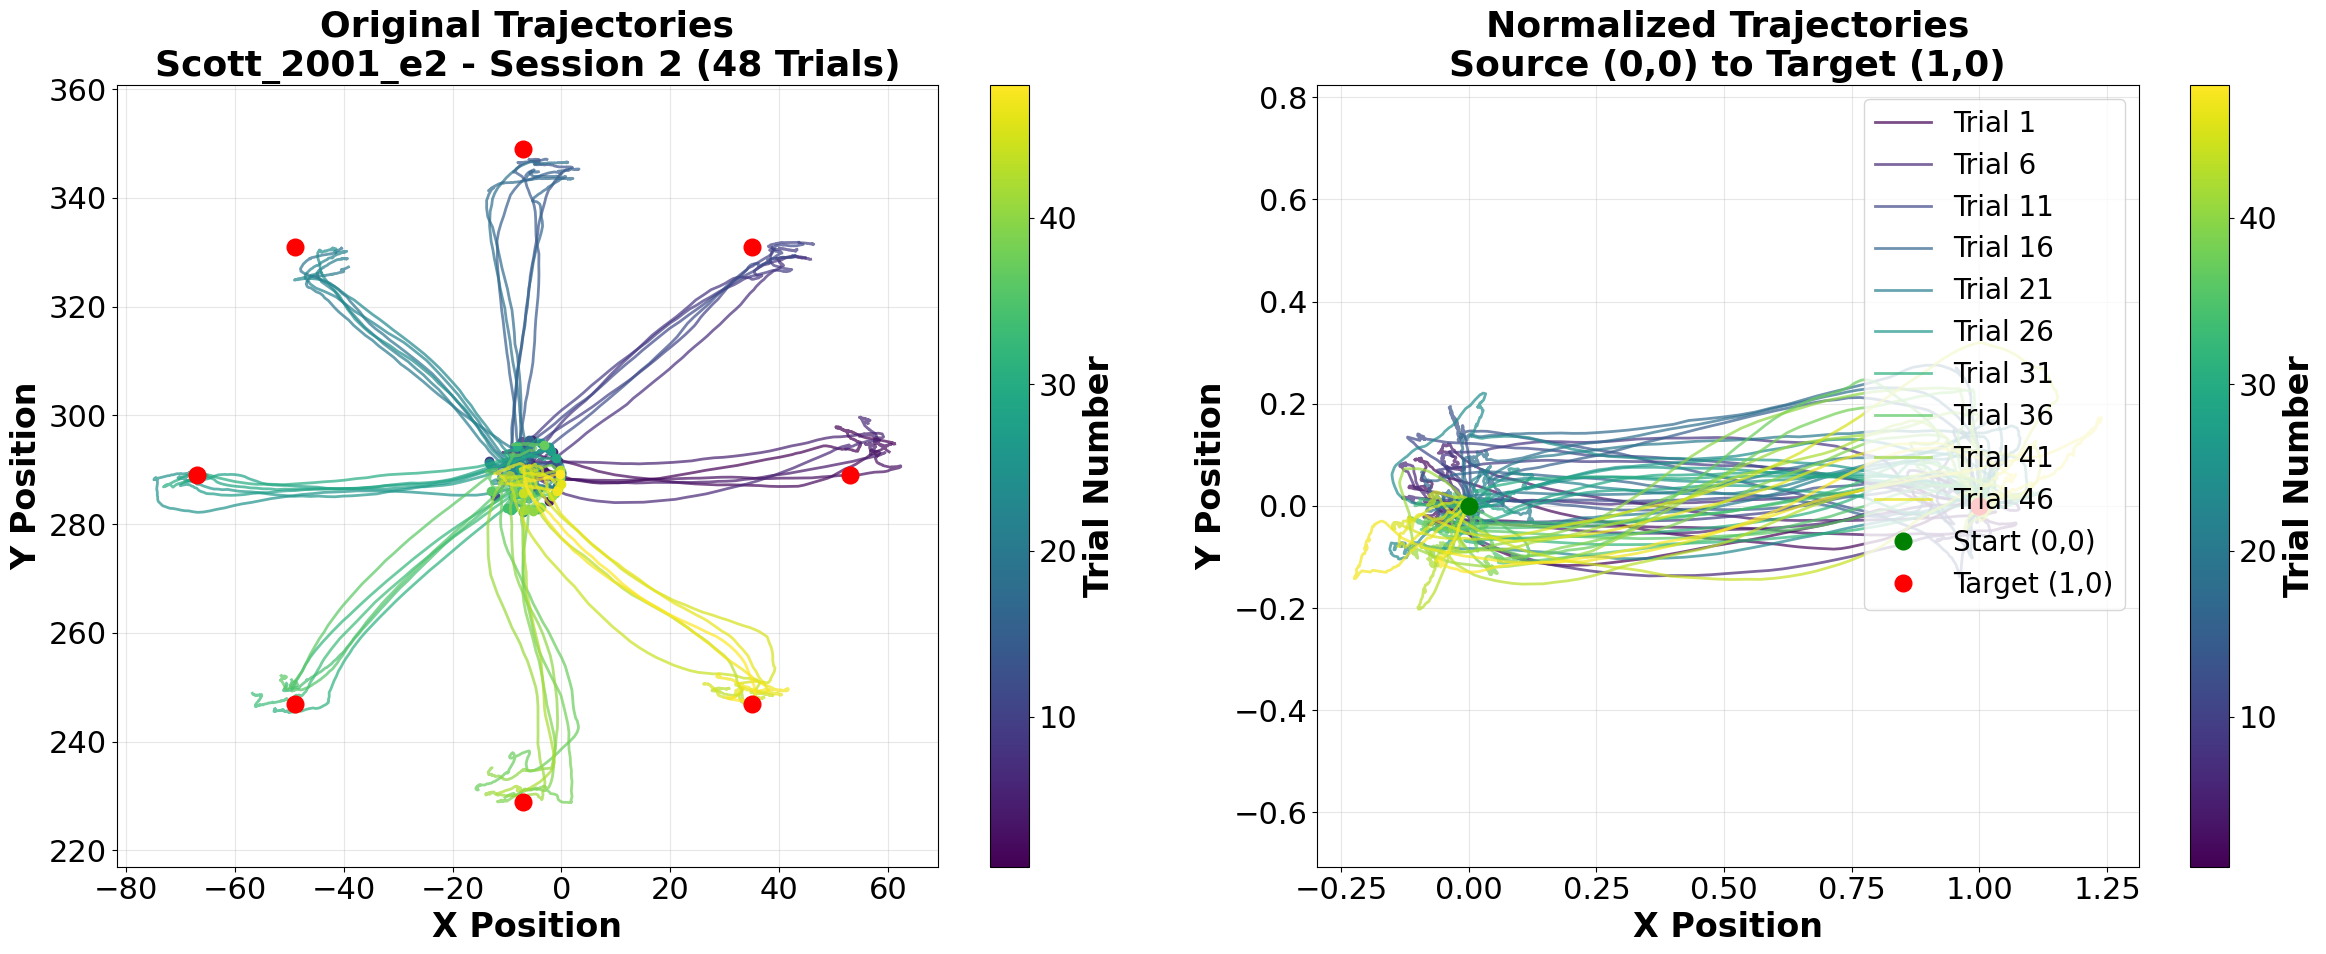


Subject Scott_2001_e2, Session 2 Statistics:
Number of trials: 48
Average original path length: 87.57 units
Average normalized path length: 1.54 units
Average completion time: 4.72 ms
Std. dev. of completion time: 0.50 ms
Min completion time: 3.92 ms
Max completion time: 6.18 ms


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

def visualize_session_trajectories(df, subject_id, session_no, save_dir=None, dpi=300, font_size=22):
    """
    Visualize original and normalized trajectories for all trials in a session.
    
    Args:
        df: DataFrame with trajectory data
        subject_id: Subject ID to filter
        session_no: Session number to filter
        save_dir: Directory to save figures (optional). If None, figures are not saved.
        dpi: DPI for saved figures (default: 300)
        font_size: Base font size for all text elements (default: 24)
    """
    # Set global font size
    plt.rcParams.update({
        'font.size': font_size,
        'axes.titlesize': font_size + 4,
        'axes.labelsize': font_size + 2,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size - 2,
        'figure.titlesize': font_size + 6
    })
    
    # Filter data for the specific subject and session
    filtered_df = df[(df['Subject_Id'] == subject_id) & 
                     (df['Session_No'] == session_no)]
    
    if len(filtered_df) == 0:
        print(f"No data found for Subject {subject_id}, Session {session_no}")
        return
    
    # Create figure with two subplots - increased size for better readability with larger fonts
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
    
    # Create a colormap for visualizing trial progression
    num_trials = len(filtered_df)
    colors = plt.cm.viridis(np.linspace(0, 1, num_trials))
    
    # Plot original trajectories
    target_points = []
    
    for idx, (_, row) in enumerate(filtered_df.iterrows()):
        # Convert path to numpy array if it's not already
        if isinstance(row['path'], str):
            path = np.array(eval(row['path']))
        else:
            path = np.array(row['path'])
        
        # Plot the original path with color based on trial progression
        ax1.plot(path[:, 0], path[:, 1], '-', linewidth=2, alpha=0.7, 
                color=colors[idx], label=f"Trial {row['Trial_No']}" if idx % 5 == 0 else "")
        
        # Get target position
        if isinstance(row['target_poisiton'], str):
            target = eval(row['target_poisiton'])
        else:
            target = row['target_poisiton']
        
        target_points.append(target)
        
        # Plot start point for each trial
        ax1.plot(path[0, 0], path[0, 1], 'o', markersize=6, color=colors[idx])
    
    # Plot unique target points (might be the same for all trials)
    unique_targets = np.unique(np.array(target_points), axis=0)
    for target in unique_targets:
        ax1.plot(target[0], target[1], 'ro', markersize=12)
    
    ax1.set_title(f'Original Trajectories\n{subject_id} - Session {session_no} ({num_trials} Trials)', 
                  fontsize=font_size + 4, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('X Position', fontsize=font_size + 2, fontweight='bold')
    ax1.set_ylabel('Y Position', fontsize=font_size + 2, fontweight='bold')
    ax1.axis('equal')
    
    # Color bar for trial progression
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(1, num_trials))
    sm.set_array([])
    cbar1 = plt.colorbar(sm, ax=ax1)
    cbar1.set_label('Trial Number', fontsize=font_size + 2, fontweight='bold')
    cbar1.ax.tick_params(labelsize=font_size)
    
    # Plot normalized trajectories
    for idx, (_, row) in enumerate(filtered_df.iterrows()):
        # Convert normalized trajectory to numpy array if it's not already
        if isinstance(row['normalized_trajectory'], str):
            norm_traj = np.array(eval(row['normalized_trajectory']))
        else:
            norm_traj = np.array(row['normalized_trajectory'])
        
        # Plot the normalized path with color based on trial progression
        ax2.plot(norm_traj[:, 0], norm_traj[:, 1], '-', linewidth=2, alpha=0.7,
                color=colors[idx], label=f"Trial {row['Trial_No']}" if idx % 5 == 0 else "")
    
    # Plot common start and target points
    ax2.plot(0, 0, 'go', markersize=12, label='Start (0,0)')   # Start point
    ax2.plot(1, 0, 'ro', markersize=12, label='Target (1,0)')  # Target point
    
    ax2.set_title(f'Normalized Trajectories\nSource (0,0) to Target (1,0)', 
                  fontsize=font_size + 4, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('X Position', fontsize=font_size + 2, fontweight='bold')
    ax2.set_ylabel('Y Position', fontsize=font_size + 2, fontweight='bold')
    ax2.axis('equal')
    ax2.legend(loc='upper right', fontsize=font_size - 2)
    
    # Color bar for trial progression
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(1, num_trials))
    sm.set_array([])
    cbar2 = plt.colorbar(sm, ax=ax2)
    cbar2.set_label('Trial Number', fontsize=font_size + 2, fontweight='bold')
    cbar2.ax.tick_params(labelsize=font_size)
    
    plt.tight_layout()
    
    # Save figures if save_dir is provided
    if save_dir is not None:
        # Create directory if it doesn't exist
        os.makedirs(save_dir, exist_ok=True)
        
        # Save combined figure
        combined_filename = f"trajectories_combined_{subject_id}_session_{session_no}.png"
        combined_filepath = os.path.join(save_dir, combined_filename)
        plt.savefig(combined_filepath, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"Combined figure saved to: {combined_filepath}")
        
        # Save individual subplots
        # Save original trajectories subplot
        fig1, ax1_single = plt.subplots(1, 1, figsize=(12, 10))
        
        # Recreate original trajectories plot
        for idx, (_, row) in enumerate(filtered_df.iterrows()):
            if isinstance(row['path'], str):
                path = np.array(eval(row['path']))
            else:
                path = np.array(row['path'])
            
            ax1_single.plot(path[:, 0], path[:, 1], '-', linewidth=2, alpha=0.7, 
                    color=colors[idx], label=f"Trial {row['Trial_No']}" if idx % 5 == 0 else "")
            ax1_single.plot(path[0, 0], path[0, 1], 'o', markersize=6, color=colors[idx])
        
        # Plot target points
        for target in unique_targets:
            ax1_single.plot(target[0], target[1], 'ro', markersize=12)
        
        ax1_single.set_title(f'Original Trajectories\n{subject_id} - Session {session_no} (All {num_trials} Trials)', 
                      fontsize=font_size + 4, fontweight='bold')
        ax1_single.grid(True, alpha=0.3)
        ax1_single.set_xlabel('X Position', fontsize=font_size + 2, fontweight='bold')
        ax1_single.set_ylabel('Y Position', fontsize=font_size + 2, fontweight='bold')
        ax1_single.axis('equal')
        
        # Add colorbar to single plot
        sm1 = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(1, num_trials))
        sm1.set_array([])
        cbar1_single = plt.colorbar(sm1, ax=ax1_single)
        cbar1_single.set_label('Trial Number', fontsize=font_size + 2, fontweight='bold')
        cbar1_single.ax.tick_params(labelsize=font_size)
        
        plt.tight_layout()
        original_filename = f"trajectories_original_{subject_id}_session_{session_no}.png"
        original_filepath = os.path.join(save_dir, original_filename)
        plt.savefig(original_filepath, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"Original trajectories saved to: {original_filepath}")
        plt.close(fig1)
        
        # Save normalized trajectories subplot
        fig2, ax2_single = plt.subplots(1, 1, figsize=(12, 10))
        
        # Recreate normalized trajectories plot
        for idx, (_, row) in enumerate(filtered_df.iterrows()):
            if isinstance(row['normalized_trajectory'], str):
                norm_traj = np.array(eval(row['normalized_trajectory']))
            else:
                norm_traj = np.array(row['normalized_trajectory'])
            
            ax2_single.plot(norm_traj[:, 0], norm_traj[:, 1], '-', linewidth=2, alpha=0.7,
                    color=colors[idx], label=f"Trial {row['Trial_No']}" if idx % 5 == 0 else "")
        
        # Plot start and target points
        ax2_single.plot(0, 0, 'go', markersize=12, label='Start (0,0)')
        ax2_single.plot(1, 0, 'ro', markersize=12, label='Target (1,0)')
        
        ax2_single.set_title(f'Normalized Trajectories\nSource (0,0) to Target (1,0)', 
                      fontsize=font_size + 4, fontweight='bold')
        ax2_single.grid(True, alpha=0.3)
        ax2_single.set_xlabel('X Position', fontsize=font_size + 2, fontweight='bold')
        ax2_single.set_ylabel('Y Position', fontsize=font_size + 2, fontweight='bold')
        ax2_single.axis('equal')
        ax2_single.legend(loc='upper right', fontsize=font_size - 2)
        
        # Add colorbar to single plot
        sm2 = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(1, num_trials))
        sm2.set_array([])
        cbar2_single = plt.colorbar(sm2, ax=ax2_single)
        cbar2_single.set_label('Trial Number', fontsize=font_size + 2, fontweight='bold')
        cbar2_single.ax.tick_params(labelsize=font_size)
        
        plt.tight_layout()
        normalized_filename = f"trajectories_normalized_{subject_id}_session_{session_no}.png"
        normalized_filepath = os.path.join(save_dir, normalized_filename)
        plt.savefig(normalized_filepath, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"Normalized trajectories saved to: {normalized_filepath}")
        plt.close(fig2)
    
    plt.show()
    
    # Calculate and print trajectory statistics
    print(f"\nSubject {subject_id}, Session {session_no} Statistics:")
    print(f"Number of trials: {num_trials}")
    
    # Calculate average path length for original trajectories
    path_lengths = []
    for _, row in filtered_df.iterrows():
        if isinstance(row['path'], str):
            path = np.array(eval(row['path']))
        else:
            path = np.array(row['path'])
            
        # Calculate total path length
        diffs = np.diff(path, axis=0)
        length = np.sum(np.sqrt(np.sum(diffs**2, axis=1)))
        path_lengths.append(length)
    
    # Calculate average path length for normalized trajectories
    norm_path_lengths = []
    for _, row in filtered_df.iterrows():
        if isinstance(row['normalized_trajectory'], str):
            norm_traj = np.array(eval(row['normalized_trajectory']))
        else:
            norm_traj = np.array(row['normalized_trajectory'])
            
        # Calculate total normalized path length (xy coordinates only)
        diffs = np.diff(norm_traj[:, :2], axis=0)
        length = np.sum(np.sqrt(np.sum(diffs**2, axis=1)))
        norm_path_lengths.append(length)
    
    # Get completion times (last time value for each trial)
    completion_times = []
    for _, row in filtered_df.iterrows():
        if isinstance(row['time_diff_ms'], str):
            times = np.array(eval(row['time_diff_ms']))
        else:
            times = np.array(row['time_diff_ms'])
        
        completion_times.append(times[-1])
    
    print(f"Average original path length: {np.mean(path_lengths):.2f} units")
    print(f"Average normalized path length: {np.mean(norm_path_lengths):.2f} units")
    print(f"Average completion time: {np.mean(completion_times):.2f} ms")
    print(f"Std. dev. of completion time: {np.std(completion_times):.2f} ms")
    print(f"Min completion time: {np.min(completion_times):.2f} ms")
    print(f"Max completion time: {np.max(completion_times):.2f} ms")
    
    # Reset matplotlib parameters to default
    plt.rcdefaults()

# Usage examples:

# 1. Display only (no saving)
# visualize_session_trajectories(monkey_df, 'Scott_2001_e2', 2)

# 2. Display and save all versions (combined + individual subplots)
visualize_session_trajectories(monkey_df, 'Scott_2001_e2', 2, save_dir='./plots/monkey/')

# 3. Display and save with custom settings - saves 3 files:
#    - trajectories_combined_[subject]_session_[no].png (side-by-side plots)
#    - trajectories_original_[subject]_session_[no].png (original trajectories only)
#    - trajectories_normalized_[subject]_session_[no].png (normalized trajectories only)
# visualize_session_trajectories(monkey_df, 'Scott_2001_e2', 2, 
#                               save_dir='./trajectory_plots', 
#                               dpi=600, 
#                               font_size=24)

In [51]:
monkey_df.to_csv("monkey_trajectory.csv", index=False)

### Trajectory Embedding uisng saved model

In [47]:
class EnhancedTrajectoryTransformer(nn.Module):
    def __init__(self, seq_len=512, input_dim=3, hidden_dim=64, nhead=8,
                 num_layers=2, dropout=0.1, metadata_dim=1):
        super().__init__()
        self.seq_len = seq_len
        self.input_dim = input_dim  # 3 for x, y, t
        self.hidden_dim = hidden_dim

        # Input embedding for trajectory
        self.embedding = nn.Linear(input_dim, hidden_dim)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(hidden_dim)

        # Metadata embedding (e.g., for task_type)
        self.metadata_embedding = nn.Sequential(
            nn.Linear(metadata_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim // 2)
        )

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim*4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)

        # Projection heads for contrastive learning
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim + hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # Decoder for trajectory reconstruction
        self.decoder = nn.Linear(hidden_dim + hidden_dim // 2, seq_len * input_dim)

    def forward(self, x, metadata=None, return_projection=True):
        # Handle input shape to ensure it's [batch_size, seq_len, input_dim]
        if len(x.shape) == 2:
            x = x.unsqueeze(0)

        # Embed trajectory features
        x = self.embedding(x)

        # Apply positional encoding and transformer
        x = self.pos_encoder(x)
        x = self.transformer(x)

        # Get encoded representation
        encoded_traj = x.mean(dim=1)  # (batch_size, hidden_dim)

        # Process metadata if provided
        if metadata is not None:
            encoded_meta = self.metadata_embedding(metadata)
            encoded = torch.cat([encoded_traj, encoded_meta], dim=1)
        else:
            # If no metadata, duplicate the last part
            encoded = torch.cat([encoded_traj, torch.zeros_like(encoded_traj[:, :self.hidden_dim // 2])], dim=1)

        # Project for contrastive learning
        projected = self.projection(encoded)

        # Decode the sequence
        decoded = self.decoder(encoded)  # (batch_size, seq_len * input_dim)
        decoded = decoded.reshape(-1, self.seq_len, self.input_dim)  # (batch_size, seq_len, input_dim)

        if return_projection:
            return encoded_traj, projected, decoded
        return encoded_traj, decoded

In [49]:

import torch
def load_trajectory_model(model_path="saved_models/spatial_transfer_learning/multi_loss_model.pt"):
    """
    Load a saved PyTorch model for trajectory embedding.
    
    Args:
        model_path: Path to the saved model
    
    Returns:
        Loaded model and the device it's loaded on
    """
    # Check if CUDA is available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    try:

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = EnhancedTrajectoryTransformer(
            seq_len=512,
            input_dim=3,  # x, y, t coordinates
            hidden_dim=128,
            nhead=8,
            num_layers=3,
            metadata_dim=1  # For task_type
        ).to(device)

        # model = models.vgg16()
        model.load_state_dict(torch.load(model_path))
        
        model = model.to(device) # Set model to gpu
        model.eval();
        # model = torch.load(model_path, map_location=device)
        
        # model.eval()  # Set to evaluation mode
        print(f"Model successfully loaded from {model_path}")
        return model, device
    except Exception as e:
        print(f"Error loading model: {e}")
        return None, device

def encode_single_trajectory(traj, model, device):
    """
    Encode a single trajectory using the trained model.
    
    Args:
        traj: Normalized trajectory as a numpy array with shape (512, 3)
        model: Loaded PyTorch model
        device: Device to run the encoding on
    
    Returns:
        Embedding as numpy array or None if encoding fails
    """
    model.eval()
    with torch.no_grad():
        if isinstance(traj, np.ndarray) and traj.shape == (512, 3):
            # Reshape to (batch_size, seq_len, features)
            traj_tensor = torch.FloatTensor(traj[:, :]).unsqueeze(0)  # Add batch dimension
            traj_tensor = traj_tensor.to(device)
            
            try:
                encoded, _, _ = model(traj_tensor)  # Assuming model returns (encoded, *, *)
                return encoded.cpu().numpy()[0]
            except Exception as e:
                print(f"Error encoding trajectory: {e}")
                return None
    return None

def add_trajectory_embeddings(df, model_path="saved_models/spatial_transfer_learning/multi_loss_model.pt", model_name="default"):
    """
    Add trajectory embeddings to the dataframe.
    
    Args:
        df: DataFrame with normalized_trajectory column
        model_path: Path to the saved model
        model_name: Name to use in the embedding column
    
    Returns:
        DataFrame with added trajectory embeddings
    """
    # Load model
    model, device = load_trajectory_model(model_path)
    if model is None:
        print("Failed to load model. Returning DataFrame without embeddings.")
        return df
    
    # Create column name for this model's embeddings
    column_name = f'trajectory_embedding_{model_name}'
    
    print(f"Adding embeddings for {model_name} model...")
    
    # Apply encoding row-wise
    embeddings = []
    total_rows = len(df)
    
    for idx, row in df.iterrows():
        # Get normalized trajectory
        if isinstance(row['normalized_trajectory'], str):
            try:
                traj = np.array(eval(row['normalized_trajectory']))
            except:
                print(f"Error parsing trajectory at row {idx}")
                embeddings.append(None)
                continue
        else:
            traj = row['normalized_trajectory']
        
        # Check if shape is as expected
        if traj.shape != (512, 3):
            print(f"Warning: Trajectory at row {idx} has shape {traj.shape}, expected (512, 3)")
            # Attempt to resample if possible
            if len(traj) > 0 and traj.shape[1] >= 3:
                # Resample to 512 points
                from scipy.interpolate import interp1d
                t_original = np.linspace(0, 1, len(traj))
                t_new = np.linspace(0, 1, 512)
                
                # Interpolate each dimension
                resampled = np.zeros((512, traj.shape[1]))
                for dim in range(traj.shape[1]):
                    f = interp1d(t_original, traj[:, dim])
                    resampled[:, dim] = f(t_new)
                
                traj = resampled
                print(f"Resampled to shape {traj.shape}")
            else:
                embeddings.append(None)
                continue
        
        # Encode the trajectory
        emb = encode_single_trajectory(traj, model, device)
        embeddings.append(emb)
        
        # Print progress
        if (idx + 1) % 100 == 0 or idx == total_rows - 1:
            print(f"Processed {idx+1}/{total_rows} trajectories")
    
    # Add embeddings to dataframe
    df[column_name] = embeddings
    
    # Print summary statistics
    n_encoded = sum(1 for emb in embeddings if emb is not None)
    embedding_dim = (
        embeddings[0].shape[0] if n_encoded > 0 and embeddings[0] is not None 
        else None
    )
    
    print(f"Number of encoded trajectories: {n_encoded}/{total_rows}")
    print(f"Embedding dimension: {embedding_dim}")
    
    return df

# Example usage
monkey_df = add_trajectory_embeddings(monkey_df, "../saved_models/STCRL_transfer_learning/models/multi_loss_model.pt", "multi_loss")

Using device: cpu
Error loading model: Error(s) in loading state_dict for EnhancedTrajectoryTransformer:
	Missing key(s) in state_dict: "embedding.weight", "embedding.bias", "pos_encoder.pe_buffer", "metadata_embedding.0.weight", "metadata_embedding.0.bias", "metadata_embedding.2.weight", "metadata_embedding.2.bias", "transformer.layers.0.self_attn.in_proj_weight", "transformer.layers.0.self_attn.in_proj_bias", "transformer.layers.0.self_attn.out_proj.weight", "transformer.layers.0.self_attn.out_proj.bias", "transformer.layers.0.linear1.weight", "transformer.layers.0.linear1.bias", "transformer.layers.0.linear2.weight", "transformer.layers.0.linear2.bias", "transformer.layers.0.norm1.weight", "transformer.layers.0.norm1.bias", "transformer.layers.0.norm2.weight", "transformer.layers.0.norm2.bias", "transformer.layers.1.self_attn.in_proj_weight", "transformer.layers.1.self_attn.in_proj_bias", "transformer.layers.1.self_attn.out_proj.weight", "transformer.layers.1.self_attn.out_proj.bias